# Puell-Multiple — a quantitative teardown 🔬
### The exact reconstruction · a HAC forward-return regression + momentum horse race · a band event study with a random-date placebo · a timer-vs-HODL sweep · a 20-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Times_tops_%26_bottoms%3F: Busted](https://img.shields.io/badge/Times_tops_%26_bottoms%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — David Puell's issuance-revenue oscillator (daily miner issuance value / its trailing 365-day average) is a contrarian top/bottom timer, sell > 4, buy < 0.5 — is tested on a **faithful reconstruction**, not a digitised proxy.

> ⚠️ **Data note.** BTC-USD daily close, yfinance, 2014-09-17 → 2026-06-30 (4,305 rows, fingerprint `9529d5277775`). The Puell Multiple is `144·reward(t)·price(t) / trailing-365d mean` — and the 144 **cancels** in the ratio, so the only non-price input is the *known halving step function*. One named approximation: real daily block counts wobble a few % around 144; that largely cancels and never moves a threshold crossing. Issuance-only (the original definition; fee-inclusive variants are out of scope). Single-survivor named on the Signal axis. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from puell_multiple import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    BTC = data.load_btc()
    PM = data.puell_multiple(BTC).dropna()
else:
    BTC = PM = None
print("real cache present:", HAVE_REAL,
      "| Puell points:", (0 if PM is None else len(PM)))

# frozen headline numbers (mirror of docs/results.md)
R = {'btc_lo': '2014-09-17', 'btc_hi': '2026-06-30', 'btc_n': 4305, 'fp_btc': '9529d5277775', 'puell_lo': '2015-09-16', 'puell_hi': '2026-06-30', 'puell_n': 3941, 'puell_min': 0.4, 'puell_med': 1.12, 'puell_max': 5.95, 'high': 4.0, 'low': 0.5, 'reg': {30: (0.0284, 0.67, 0.0037, 3911), 90: (0.0027, 0.02, 0.0, 3851), 180: (-0.1616, -0.74, 0.0155, 3761)}, 'horse_puell_t': -1.76, 'horse_mom_t': 1.7, 'band': {30: {'bottom': (6.79, 6.54, 0.75, 0.08, 0.479, 75), 'neutral': (6.84, 3.03, 0.57, 0.25, None, 3814), 'top': (-17.13, -20.3, 0.14, -4.6, 0.0, 22)}, 90: {'bottom': (2.01, -1.81, 0.44, -11.1, 1.0, 75), 'neutral': (24.03, 11.17, 0.61, 0.65, None, 3754), 'top': (-44.18, -46.76, 0.0, -19.14, 0.0, 22)}, 180: {'bottom': (60.93, 49.62, 0.61, 0.67, 0.304, 75), 'neutral': (55.59, 31.69, 0.66, 0.22, None, 3664), 'top': (-56.89, -59.87, 0.0, -43.47, 0.0, 22)}}, 'top_days': 22, 'top_episode': '2017-12-04 -> 2018-01-06', 'bottom_days': 75, 'bottom_episodes': 3, 'placebo_draws': 20000, 'years': 10.79, 'n_flips': 7, 'exposure': 99.42, 'strat_total': 24841.1, 'strat_cagr': 66.8, 'strat_sharpe': 1.114, 'bh_total': 25461.4, 'bh_cagr': 67.18, 'bh_sharpe': 1.107, 'excess_cagr': -0.97, 'excess_t': -0.21, 'sweep': {3.0: (18921.1, 97.6, 1.09), 3.5: (20377.3, 98.9, 1.09), 4.0: (24841.1, 99.4, 1.11), 4.5: (22944.2, 99.6, 1.1)}, 'syn_planted_slope': -11.78, 'syn_planted_t': -26.09, 'syn_null_mean': 0.06, 'syn_null_sd': 1.22, 'syn_null_fire': 1}


real cache present: True | Puell points: 3941


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | forward-return-on-log(Puell) best HAC **t = 0.67** (sign not stably contrarian), R² ≈ 0; horse-race t = -1.76; buy band **+2%** < neutral **+24%** at 90d |
| **Tradability** | `MIRAGE` | timer **+24,841%** vs B&H **+25,461%**, 99% invested, excess -0.97%/yr (HAC t = -0.21) |
| **Times tops & bottoms?** | `BUSTED` | sell band = one 2017 blow-off (n_eff ≈ 1); buy band worse than a random day |

> 💡 In plain words: the metric is a repackaged 365-day price ratio; on the real tape it neither predicts returns nor beats holding, and its one dramatic number is a single historical event with a fake-precise *t* bolted on.

## 1 · The claim, and why the reconstruction is exact

Let $I_t = b \cdot R(t) \cdot P_t$ be daily miner **issuance value**, with $b$ = blocks/day (144), $R(t)$ the halving-scheduled block reward, $P_t$ the BTC price. The Puell Multiple is

$$\text{Puell}_t = \frac{I_t}{\frac{1}{365}\sum_{k=0}^{364} I_{t-k}} = \frac{R(t) P_t}{\frac{1}{365}\sum_{k} R(t-k) P_{t-k}}.$$

The constant $b$ **cancels**. $R(t)$ is a deterministic step function. So the metric is a *pure function of the price tape and the halving schedule* — a genuine reconstruction of the canonical issuance-only Puell Multiple, not a proxy. Note the structural consequence: **within** a halving epoch $R$ is constant, so $\text{Puell}_t = P_t / \overline{P}_{365}$ — a 365-day price ratio. The only thing $R(t)$ adds is a ~1-year suppression after each halving (the denominator still holds pre-halving days at double reward). The contrarian claims:

- **H₁ (predictive).** $E[r_{t\to t+h}\mid \log\text{Puell}_t]$ has a **negative** slope with $|t|\ge 2$.
- **H₂ (tradable).** A buy-low/sell-high timer beats buy-and-hold net of costs.

## 2 · So what? — inference design

Two honest hazards to design around. **(a) Overlap.** Forward $h$-day returns on a daily grid overlap heavily, so OLS *t*-stats are badly inflated; we use Newey-West (HAC) errors with lag $\ge h$. **(b) Clustered bands.** The band days are numerous but *not independent* — the top band is a single 2017-18 episode, so a Welch *t* over its ~22 days is fake precision. The guard is a **random-date placebo** (20 seeds × 1,000 draws of the same day-count), reported alongside the Welch *t* with a loud caveat, and — the ultimate arbiter for H₂ — the **excess-of-buy-and-hold** return with its own HAC *t*.

## 3 · How we'd know — the protocol

- **Metric.** 3,941 daily Puell values 2015-09-16 → 2026-06-30 (min 0.40, median 1.12, max 5.95), reconstructed from price + the hardcoded halving table.
- **Bands.** top = Puell ≥ 4 (sell), bottom = Puell ≤ 0.5 (buy), else neutral — David Puell's canonical thresholds.
- **Tape.** BTC-USD daily close 2014-09-17 → 2026-06-30. As-of 2026-06-30 (last complete month).
- **Signal.** forward 30/90/180-day BTC log-return on log(Puell), HAC lag = horizon; a horse race adds trailing-180d price momentum.
- **Bands.** mean forward return per band, Welch *t* + 20×1,000 random-date placebo.
- **Execution.** Puell known at close t; timer exposure applies to t+1 (one-day lag, documented once); 10 bps one-way × NAV per flip; long/flat, no borrow; price-only.
- **Control.** synthetic (Puell, price) world with a tunable contrarian link; the null must read ~zero across 20 seeds.

## 4 · The teardown

### 4a · The reconstruction, and the halving imprint

The reconstructed metric with its sell/buy bands, plus the block-reward step underneath it. The ~1-year post-halving suppression is the only thing the metric adds over a plain 365-day price ratio.

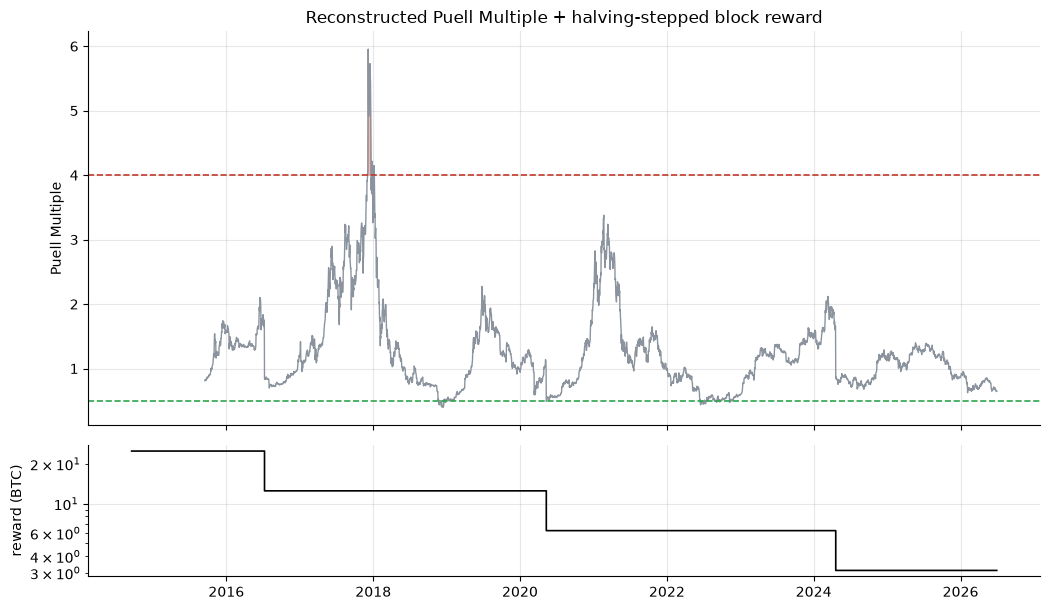

SELL band (>=4): 22 days, all one blow-off cluster 2017-12-04 -> 2018-01-06
BUY band (<=0.5): 75 days across ~3 episodes (2018 bear, 2020 halving-day dip, 2022 FTX bear)


In [2]:
if HAVE_REAL:
    pm = PM; reward = data.reward_at(BTC.index)
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(10.6, 6.2), sharex=True,
                                 gridspec_kw={'height_ratios': [3, 1]})
    a1.plot(pm.index, pm.values, color=GREY, lw=1.0)
    a1.axhline(R['high'], color=RED, ls='--', lw=1.2); a1.axhline(R['low'], color=GREEN, ls='--', lw=1.2)
    a1.fill_between(pm.index, R['high'], pm.values, where=(pm.values >= R['high']), color=RED, alpha=.35)
    a1.fill_between(pm.index, R['low'], pm.values, where=(pm.values <= R['low']), color=GREEN, alpha=.35)
    a1.set_ylabel('Puell Multiple'); a1.set_title('Reconstructed Puell Multiple + halving-stepped block reward')
    a2.step(reward.index, reward.values, where='post', color='k', lw=1.2)
    a2.set_ylabel('reward (BTC)'); a2.set_yscale('log')
    plt.tight_layout(); plt.show()
else:
    print('(offline) frozen: Puell range', R['puell_min'], '..', R['puell_max'])
print(f"SELL band (>=4): {R['top_days']} days, all one blow-off cluster {R['top_episode']}")
print(f"BUY band (<=0.5): {R['bottom_days']} days across ~{R['bottom_episodes']} episodes "
      '(2018 bear, 2020 halving-day dip, 2022 FTX bear)')

> 💡 In plain words: the sell band is not a repeatable signal — it is essentially the **single** 2017 top (three runs all inside five weeks). Any statistic computed on it is really a statistic about one event.

### 4b · Predictive regression — log(Puell) → forward return (HAC)

$r_{t\to t+h} = a + b\,\log(\text{Puell}_t) + e$. A contrarian gauge needs $b<0$, $|t|\ge 2$.

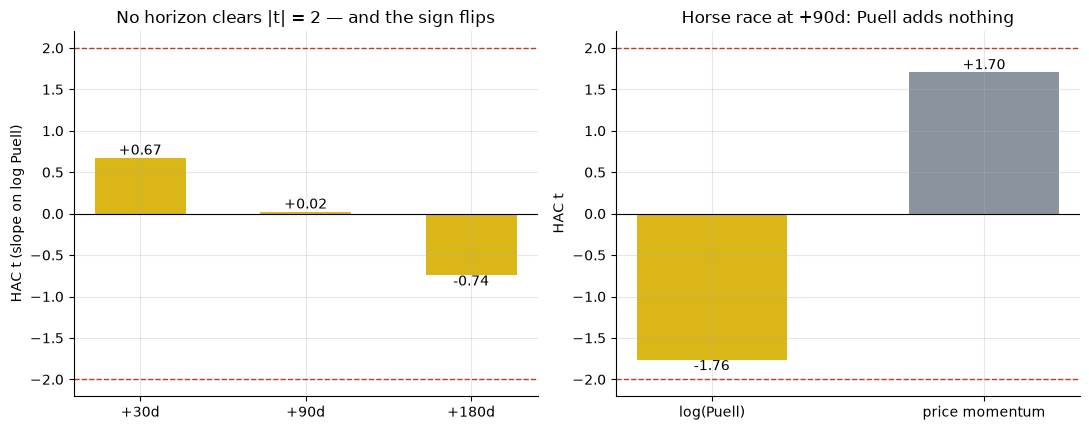

+30d: HAC t = +0.67
+90d: HAC t = +0.02
+180d: HAC t = -0.74
horse race +90d: Puell t = -1.76, price-mom t = +1.70


In [3]:
if HAVE_REAL:
    hz = [30, 90, 180]
    ts = [st.predictive_regression(PM, BTC, horizon=h)['t_puell'] for h in hz]
    rc = st.predictive_regression(PM, BTC, horizon=90, add_price_control=True)
    puell_t, mom_t = rc['t_puell'], rc['t_price']
else:
    hz = [30, 90, 180]; ts = [R['reg'][h][1] for h in hz]
    puell_t, mom_t = R['horse_puell_t'], R['horse_mom_t']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.4))
x = np.arange(len(hz))
a1.bar(x, ts, color=[RED if abs(t) >= 2 else AMBER for t in ts], width=.55)
a1.axhline(2, ls='--', c=RED, lw=1); a1.axhline(-2, ls='--', c=RED, lw=1); a1.axhline(0, c='k', lw=.8)
for i, v in enumerate(ts): a1.annotate(f'{v:+.2f}', (x[i], v), ha='center', va='bottom' if v>=0 else 'top')
a1.set_xticks(x); a1.set_xticklabels([f'+{h}d' for h in hz]); a1.set_ylabel('HAC t (slope on log Puell)')
a1.set_title('No horizon clears |t| = 2 — and the sign flips')
a2.bar(['log(Puell)', 'price momentum'], [puell_t, mom_t], color=[AMBER, GREY], width=.55)
a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(0, c='k', lw=.8)
for i, v in enumerate([puell_t, mom_t]): a2.annotate(f'{v:+.2f}', (i, v), ha='center', va='bottom' if v>=0 else 'top')
a2.set_ylabel('HAC t'); a2.set_title('Horse race at +90d: Puell adds nothing')
plt.tight_layout(); plt.show()
for h, t in zip(hz, ts): print(f'+{h}d: HAC t = {t:+.2f}')
print(f'horse race +90d: Puell t = {puell_t:+.2f}, price-mom t = {mom_t:+.2f}')

> 💡 In plain words: the best statistic is **0.67** and the slope isn't even reliably the contrarian sign (positive at 30/90 days, negative at 180). Controlling for price momentum, Puell's own *t* is **-1.76** — still short of 2, and only borderline-negative once the price trend is removed. There is no robust forward information here.

### 4c · Band event study — the placebo unmasks the clustering

Mean forward return per band vs the unconditional distribution, Welch *t*, and the random-date placebo (right-tailed for buy, left-tailed for sell — the contrarian direction).

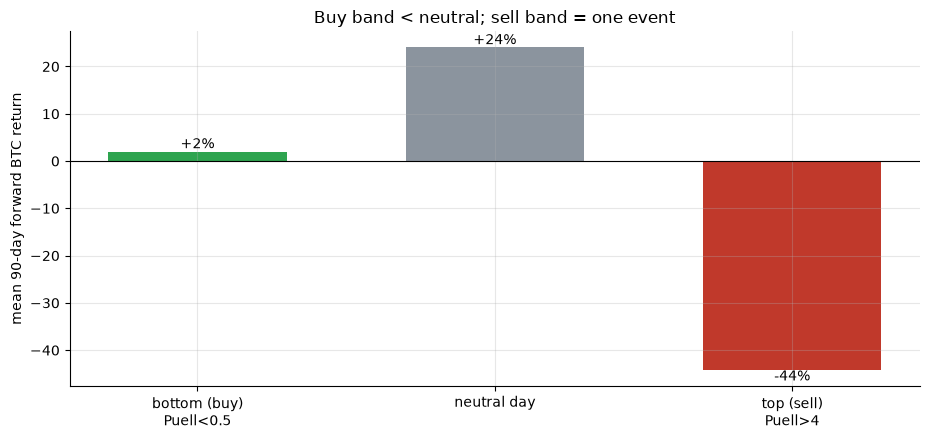

bottom (buy)  : mean +2.0%  Welch t -11.10  placebo p 1.000  n=75
top (sell)    : mean -44.2%  Welch t -19.14  placebo p 0.000  n=22
neutral day    : mean +24.0%


In [4]:
if HAVE_REAL:
    tab = st.state_forward_stats(PM, BTC, horizon=90, high=R['high'], low=R['low'])
    rows = [('bottom (buy)', tab.loc['bottom (buy)']), ('top (sell)', tab.loc['top (sell)'])]
    disp = {k: (v['mean_pct'], v['welch_t'], v['placebo_p'], int(v['n'])) for k, v in rows}
    neutral_mean = tab.loc['neutral', 'mean_pct']
else:
    b = R['band'][90]
    disp = {'bottom (buy)': (b['bottom'][0], b['bottom'][3], b['bottom'][4], b['bottom'][5]),
            'top (sell)':   (b['top'][0], b['top'][3], b['top'][4], b['top'][5])}
    neutral_mean = b['neutral'][0]
fig, ax = plt.subplots(figsize=(9.4, 4.5))
labels = ['bottom (buy)\nPuell<0.5', 'neutral day', 'top (sell)\nPuell>4']
vals = [disp['bottom (buy)'][0], neutral_mean, disp['top (sell)'][0]]
ax.bar(labels, vals, color=[GREEN, GREY, RED], width=.6)
for i, v in enumerate(vals): ax.annotate(f'{v:+.0f}%', (i, v), ha='center', va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('mean 90-day forward BTC return')
ax.set_title('Buy band < neutral; sell band = one event')
plt.tight_layout(); plt.show()
for k, (m, t, p, n) in disp.items():
    print(f'{k:<14}: mean {m:+.1f}%  Welch t {t:+.2f}  placebo p {p:.3f}  n={n}')
print(f'neutral day    : mean {neutral_mean:+.1f}%')

> 💡 In plain words: the buy band earns **+2%** vs a neutral day's **+24%** (placebo *p* = 1.00 — a random day does at least as well essentially always): the capitulation-buy half is worse than nothing. The sell band's placebo *p* rounds to 0.000 and its Welch *t* is **-19.1** — but that spans **22** days that are **one** 2017-18 event. Drawing 22 *scattered* random days from a mostly-rising tape will of course rarely match a single concentrated crash; the placebo rejecting here is the clustering, not a repeatable edge. n_effective ≈ 1.

### 4d · Timer vs buy-and-hold — the decisive test for H₂

Sell to cash when Puell ≥ 4 (one-day lag), else long; 10 bps one-way × NAV per flip; compared to continuous buy-and-hold, and swept across the sell threshold.

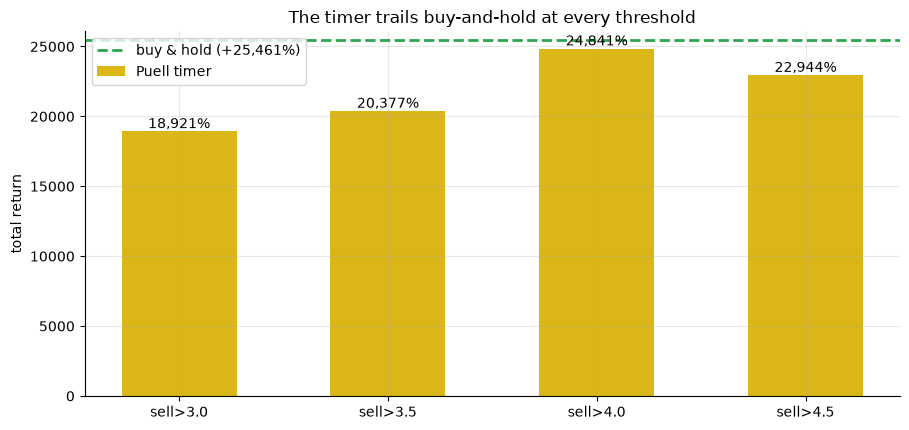

timer (sell>4): +24,841%  vs  buy&hold +25,461%
excess -0.97%/yr, HAC t = -0.21; invested 99.4% of the time (7 flips)


In [5]:
if HAVE_REAL:
    sweep = {hi: st.backtest_timing(PM, BTC, high=hi, cost_bps=10.0) for hi in [3.0,3.5,4.0,4.5]}
    tots = [sweep[hi]['strat_total_pct'] for hi in [3.0,3.5,4.0,4.5]]
    bh = sweep[4.0]['bh_total_pct']
else:
    tots = [R['sweep'][hi][0] for hi in [3.0,3.5,4.0,4.5]]; bh = R['bh_total']
fig, ax = plt.subplots(figsize=(9.2, 4.4))
xl = ['sell>3.0','sell>3.5','sell>4.0','sell>4.5']
ax.bar(xl, tots, color=AMBER, width=.55, label='Puell timer')
ax.axhline(bh, color=GREEN, lw=2, ls='--', label=f'buy & hold (+{bh:,.0f}%)')
for i, v in enumerate(tots): ax.annotate(f'{v:,.0f}%', (i, v), ha='center', va='bottom')
ax.set_ylabel('total return'); ax.set_title('The timer trails buy-and-hold at every threshold')
ax.legend(); plt.tight_layout(); plt.show()
print(f"timer (sell>4): +{R['strat_total']:,.0f}%  vs  buy&hold +{R['bh_total']:,.0f}%")
print(f"excess {R['excess_cagr']:+.2f}%/yr, HAC t = {R['excess_t']:+.2f}; "
      f"invested {R['exposure']:.1f}% of the time ({R['n_flips']} flips)")

> 💡 In plain words: at **every** threshold the timer ends **below** the buy-and-hold line. Puell only clears 4 at the peak itself, so the rule is **99%** invested and its brief cash windows re-enter into the still-ongoing bear — the excess return is **-0.97%/yr** with HAC *t* = **-0.21**. Not a timing edge; a small timing cost.

### 4e · Synthetic control — the engine is honest

Point the *same* predictive regression at a synthetic (Puell, price) world with a tunable contrarian link. It must find a planted effect and read ~zero on the null (checked over 20 seeds).

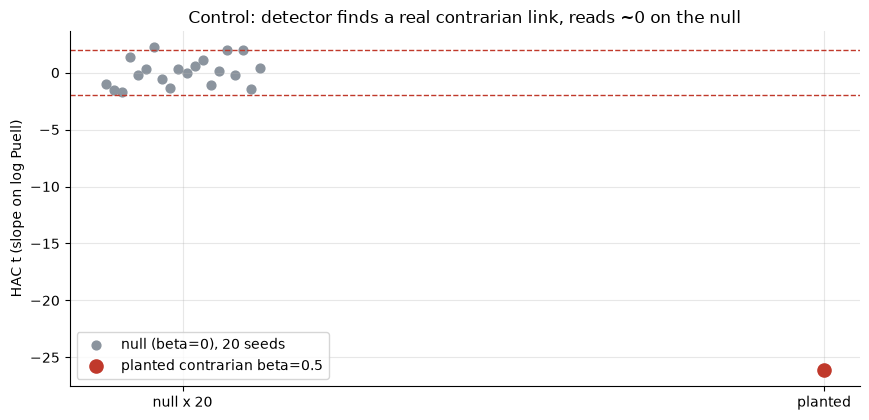

planted beta=0.5: HAC t = -26.09
null 20 seeds: mean t = +0.06 (sd 1.22), |t|>=2 in 1/20 seeds


In [6]:
null_t = []
for s in range(20):
    pu, pr = data.synthetic_world(beta=0.0, seed=763 + s)
    null_t.append(st.synthetic_detect(pu, pr, horizon=30)['t_puell'])
null_t = np.asarray(null_t)
pu, pr = data.synthetic_world(beta=0.5, seed=763)
planted_t = st.synthetic_detect(pu, pr, horizon=30)['t_puell']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_t, color=GREY, s=40, label='null (beta=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5, label='planted contrarian beta=0.5')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('HAC t (slope on log Puell)')
ax.set_title('Control: detector finds a real contrarian link, reads ~0 on the null')
ax.legend(); plt.tight_layout(); plt.show()
print(f'planted beta=0.5: HAC t = {planted_t:+.2f}')
print(f'null 20 seeds: mean t = {null_t.mean():+.2f} (sd {null_t.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_t) >= 2).sum()}/20 seeds')

> 💡 In plain words: the detector nails a planted contrarian link (t = -26.1) and averages ~zero on the null (+0.06, |t|≥2 in 1/20). The machinery works; the real BTC tape simply has no such link for the Puell Multiple to exploit. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — forward-return-on-log(Puell) never clears |t| = 2 (best **0.67**, sign not stably contrarian, R² ≈ 0), the horse race leaves Puell at **t = -1.76**, and the buy band (**+2%**) underperforms a neutral day (**+24%**). The only dramatic number — the sell band's **-44%** — is a single 2017-18 blow-off (n_eff ≈ 1) with an autocorrelation-inflated Welch *t*.
- **Tradability `MIRAGE`** — the buy-low/sell-high timer is **99%** buy-and-hold and **trails** it net of costs at every threshold (**+24,841%** vs **+25,461%**, -0.97%/yr, HAC t = -0.21). Any CAGR is long exposure to a single survivor.
- **"Times tops & bottoms?" `BUSTED`** — one top, zero tradable bottoms.

## 6 · Going further

- **The reconstruction is the lesson.** Because the blocks/day constant cancels and the reward is a known step, within a halving epoch the Puell Multiple *is* price / trailing-365d-mean(price). Most famous "on-chain" valuation oscillators collapse to a price transform once you rebuild them; the burden of proof is on the extra ingredient (here, the halving imprint) to add information beyond price — and it doesn't.
- **A fairer test of the sell band** would resample *contiguous* blocks rather than scattered days in the placebo, and would need several independent top episodes to have any power — we effectively have one.
- **Dedup map:** [293-mvrv-ratio](../../293-mvrv-ratio/) (MVRV valuation band, NONE/MIRAGE — same family, different metric and cadence), [221-mayer-multiple](../../221-mayer-multiple/) (price / 200-day SMA — the Puell Multiple's within-epoch cousin), [663-hash-ribbons](../../663-hash-ribbons/) (hashrate crossover buy event, WEAK/FRAGILE), [323-btc-halving](../../323-btc-halving/) (the halving calendar — the same schedule, tested as a date not a revenue oscillator), [210-crypto-trend](../../210-crypto-trend/) (200-day price trend-following).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*